<a href="https://colab.research.google.com/github/emanaak04-svg/medical-xai/blob/main/09_lime_xai_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transparent Medical Image Classification via Explainable AI
## Phase 5 — LIME + Three-Way XAI Comparison

**Objective:** This notebook implements LIME (Local Interpretable Model-agnostic
Explanations) and produces a critical three-way comparison of Grad-CAM, SHAP,
and LIME on identical chest X-ray images. The goal is not just to show three
methods — but to analyse where they agree, where they disagree, and which
produces the most clinically reliable explanation.

**Core question:** Do Grad-CAM, SHAP, and LIME tell the same story about
how this model makes decisions — or do they contradict each other?


**Author:** Eman Ayman Ahmed Abukhousa  
**Program:** BSc Data Science & Artificial Intelligence, IITG — Year 3

## 01. Rebuild Model & Load Checkpoint

The trained ResNet-50 checkpoint is reloaded — identical to 07 and 08.
All three XAI methods will run on the same model and the same images to ensure
the comparison is valid and fair.

In [1]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
from google.colab import drive

drive.mount('/content/drive')

try:
    import cv2
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'opencv-python-headless'], check=True)
    import cv2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

model = models.resnet50(weights=None)
model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(256, 1)
)

checkpoint_path = '/content/drive/MyDrive/medical-xai/best_model.pth'
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model = model.to(device)
model.eval()

# Disable inplace operations — required for XAI methods
for module in model.modules():
    if isinstance(module, nn.ReLU):
        module.inplace = False

print(f"Compute device : {device}")
print("Checkpoint loaded — model in eval mode.")


Mounted at /content/drive
Compute device : cuda
Checkpoint loaded — model in eval mode.


## 02. Install & Import LIME

LIME (Local Interpretable Model-agnostic Explanations) works by creating
perturbed versions of the input image — masking different superpixel segments
— and running the model on each version. A local linear model is then fitted
to identify which segments most influenced the prediction. Unlike Grad-CAM
which uses gradients and SHAP which uses game theory, LIME is completely
model-agnostic — it only needs access to the model's output probabilities.


In [2]:
import subprocess
subprocess.run(['pip', 'install', 'lime', '-q'], check=True)

from lime import lime_image
from skimage.segmentation import mark_boundaries
import shap

print("LIME and SHAP imported successfully.")

LIME and SHAP imported successfully.


## 03. Preprocessing, Dataset & Helper Functions

The same normalisation parameters from training are applied across all three
methods to ensure consistency. The dataset is downloaded from Kaggle and the
same images used in Day 7 and Day 8 are loaded here — this is essential for
a valid three-way comparison.

In [3]:
from google.colab import userdata

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(f'{{"username":"emanaymanabukhousa","key":"{userdata.get("KAGGLE_KEY")}"}}\n')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

!pip install -q kaggle
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia \
    -p /content/images --unzip

print("Done.")
!ls /content/images/chest_xray/

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:09<00:00, 255MB/s]

Done.
chest_xray  __MACOSX  test  train  val


## 04. Load Images & Define Predict Functions

The same test images are loaded for all three methods. Two predict functions
are defined — one that accepts normalised tensors for Grad-CAM, and one that
accepts raw numpy arrays for LIME and SHAP. Both apply the same normalisation
internally to ensure the model always receives correctly preprocessed input.

In [4]:
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5330, 0.5330, 0.5330],
                         std=[0.0349, 0.0349, 0.0349]),
])

def load_image(path):
    img_pil = Image.open(path).convert('RGB').resize((224, 224))
    tensor = val_transforms(img_pil).unsqueeze(0)
    return img_pil, tensor

# For LIME and SHAP — accepts numpy array, applies normalisation internally
def predict_fn(images):
    images = torch.tensor(images, dtype=torch.float32).permute(0, 3, 1, 2)
    images = images.to(device)
    # Apply normalisation
    mean = torch.tensor([0.5330, 0.5330, 0.5330]).view(1,3,1,1).to(device)
    std  = torch.tensor([0.0349, 0.0349, 0.0349]).view(1,3,1,1).to(device)
    images = (images - mean) / std
    with torch.no_grad():
        output = torch.sigmoid(model(images))
    probs = output.squeeze(-1).cpu().numpy()
    # LIME expects 2-class output — [prob_normal, prob_pneumonia]
    return np.stack([1 - probs, probs], axis=1)

test_dir = '/content/images/chest_xray/test'

normal_img_path = os.path.join(
    test_dir, 'NORMAL',
    os.listdir(os.path.join(test_dir, 'NORMAL'))[0]
)
pneumo_img_path = os.path.join(
    test_dir, 'PNEUMONIA',
    os.listdir(os.path.join(test_dir, 'PNEUMONIA'))[0]
)

normal_pil, normal_tensor = load_image(normal_img_path)
pneumo_pil, pneumo_tensor = load_image(pneumo_img_path)

normal_np = np.array(normal_pil).astype(np.float32) / 255.0
pneumo_np = np.array(pneumo_pil).astype(np.float32) / 255.0

print(f"Normal image  : {os.path.basename(normal_img_path)}")
print(f"Pneumonia image: {os.path.basename(pneumo_img_path)}")
print(f"Image shape   : {normal_np.shape}")

Normal image  : IM-0067-0001.jpeg
Pneumonia image: person91_bacteria_447.jpeg
Image shape   : (224, 224, 3)


## 05. Implement Grad-CAM

Grad-CAM is reimplemented here using the same approach as Day 7 — hooks on
layer4[2].conv3. This ensures the Grad-CAM explanation is generated on the
exact same image and model state as SHAP and LIME, making the three-way
comparison valid.

In [5]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()
        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()
        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor):
        input_tensor = input_tensor.to(device)
        input_tensor.requires_grad = True
        output = self.model(input_tensor)
        prob = torch.sigmoid(output)[0][0]
        self.model.zero_grad()
        prob.backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = cam.squeeze().cpu().numpy()
        cam = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()
        return cam, prob.item()

gradcam = GradCAM(model, model.layer4[2].conv3)

# Generate Grad-CAM for both images
normal_cam, normal_prob_gc   = gradcam.generate(normal_tensor.to(device))
pneumo_cam, pneumo_prob_gc   = gradcam.generate(pneumo_tensor.to(device))

print(f"Grad-CAM computed.")
print(f"Normal   — prob: {normal_prob_gc:.3f}")
print(f"Pneumonia — prob: {pneumo_prob_gc:.3f}")

Grad-CAM computed.
Normal   — prob: 0.019
Pneumonia — prob: 1.000


## 06. Implement SHAP

SHAP PartitionExplainer is applied to the same images using the blur masker
baseline — identical setup to Day 8. SHAP values quantify the direction and
magnitude of each region's contribution to the final prediction.

In [6]:
class ModelWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        return torch.sigmoid(self.model(x)).squeeze(-1)

wrapped_model = ModelWrapper(model).to(device)
wrapped_model.eval()

masker = shap.maskers.Image("blur(128,128)", (224, 224, 3))

def predict_shap(imgs):
    imgs = torch.tensor(imgs, dtype=torch.float32).permute(0,3,1,2).to(device)
    mean = torch.tensor([0.5330, 0.5330, 0.5330]).view(1,3,1,1).to(device)
    std  = torch.tensor([0.0349, 0.0349, 0.0349]).view(1,3,1,1).to(device)
    imgs = (imgs - mean) / std
    with torch.no_grad():
        return wrapped_model(imgs).cpu().numpy()

explainer_shap = shap.Explainer(predict_shap, masker)

normal_shap_vals = explainer_shap(normal_np[np.newaxis, ...],
                                   max_evals=500, batch_size=50)
pneumo_shap_vals = explainer_shap(pneumo_np[np.newaxis, ...],
                                   max_evals=500, batch_size=50)

normal_shap_map = normal_shap_vals.values[0].mean(axis=-1)
pneumo_shap_map = pneumo_shap_vals.values[0].mean(axis=-1)

print("SHAP computed.")
print(f"Normal SHAP shape  : {normal_shap_map.shape}")
print(f"Pneumonia SHAP shape: {pneumo_shap_map.shape}")

SHAP computed.
Normal SHAP shape  : (224, 224)
Pneumonia SHAP shape: (224, 224)


## 07. Implement LIME

LIME generates explanations by creating perturbed versions of the input image
— randomly masking superpixel segments — and running the model on each version.
A local linear model is fitted to identify which segments most influenced the
prediction. num_samples=1000 gives stable explanations at reasonable
computational cost. The top 10 most influential superpixels are highlighted.

In [7]:
explainer_lime = lime_image.LimeImageExplainer()

def get_lime_explanation(img_np, num_samples=1000):
    explanation = explainer_lime.explain_instance(
        img_np.astype(np.double),
        predict_fn,
        top_labels=2,
        hide_color=0,
        num_samples=num_samples
    )
    # Get mask for pneumonia class (label 1)
    temp, mask = explanation.get_image_and_mask(
        label=1,
        positive_only=False,
        num_features=10,
        hide_rest=False
    )
    return explanation, temp, mask

print("Running LIME on normal image...")
normal_lime_exp, normal_lime_temp, normal_lime_mask = get_lime_explanation(normal_np)
print("Running LIME on pneumonia image...")
pneumo_lime_exp, pneumo_lime_temp, pneumo_lime_mask = get_lime_explanation(pneumo_np)

print("LIME computed.")

Running LIME on normal image...


  0%|          | 0/1000 [00:00<?, ?it/s]

Running LIME on pneumonia image...


  0%|          | 0/1000 [00:00<?, ?it/s]

LIME computed.


## 08. Three-Way XAI Comparison

The core research contribution of this project. Grad-CAM, SHAP, and LIME
are visualised side by side on the same chest X-ray images. This allows
direct comparison of where each method focuses, whether they agree or
disagree, and which produces the most clinically meaningful explanation.

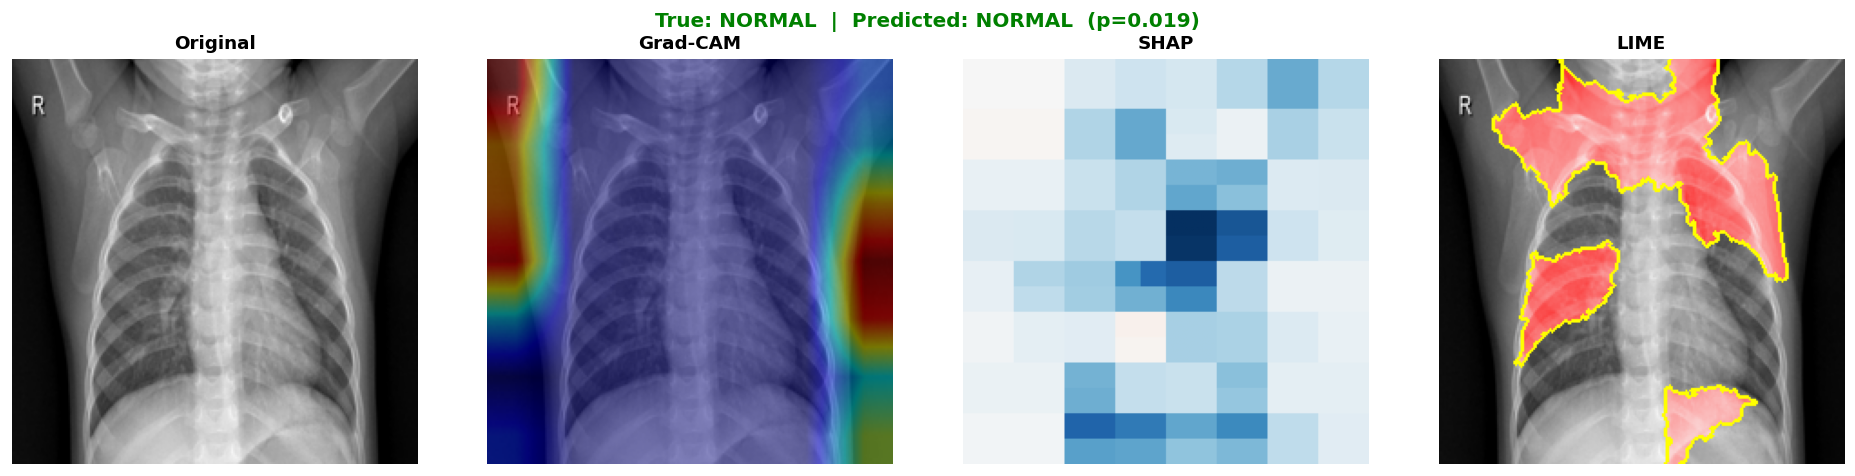

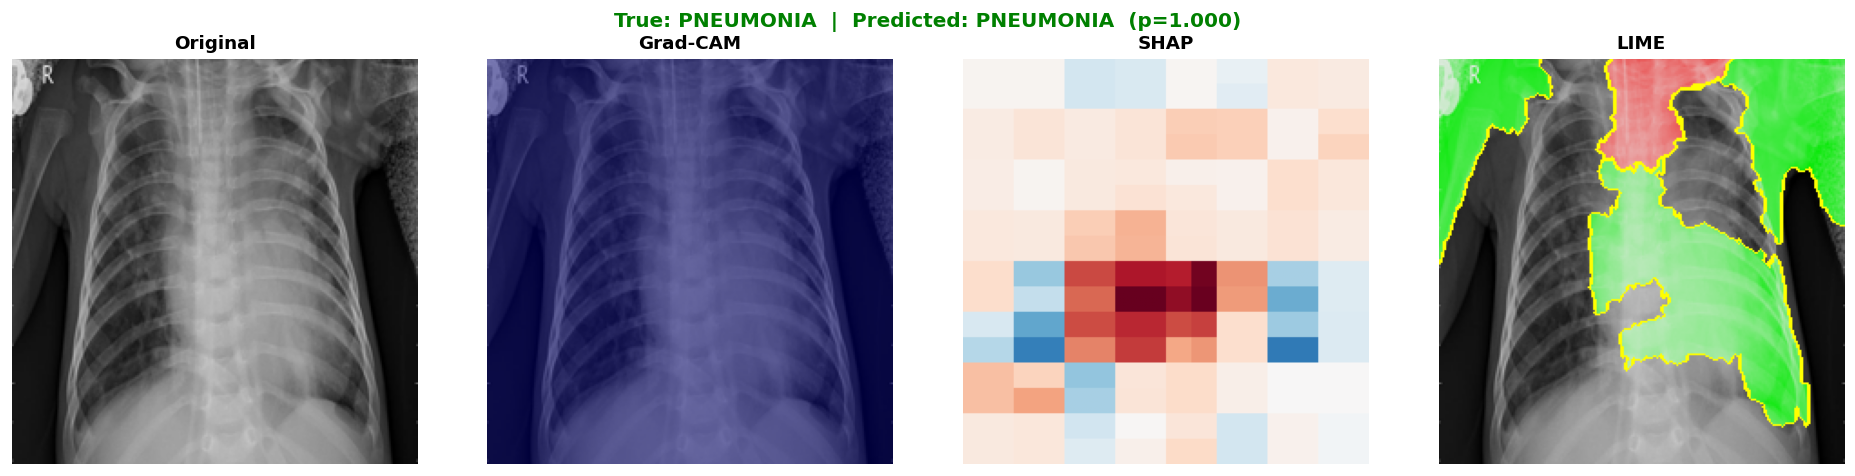

In [8]:
def overlay_cam(img_pil, cam):
    cam_uint8 = np.uint8(255 * cam)
    heatmap = cv2.applyColorMap(
        cv2.resize(cam_uint8, (224, 224)), cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    img_np = np.array(img_pil)
    return np.uint8(0.45 * heatmap_rgb + 0.55 * img_np)

def plot_three_way(img_pil, cam, shap_map, lime_temp, lime_mask,
                   true_label, prob):
    pred_label = "PNEUMONIA" if prob >= 0.5 else "NORMAL"
    colour = 'green' if pred_label == true_label else 'red'

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    # Original
    axes[0].imshow(img_pil, cmap='gray')
    axes[0].set_title('Original', fontsize=11, fontweight='bold')
    axes[0].axis('off')

    # Grad-CAM
    overlay = overlay_cam(img_pil, cam)
    axes[1].imshow(overlay)
    axes[1].set_title('Grad-CAM', fontsize=11, fontweight='bold')
    axes[1].axis('off')

    # SHAP
    abs_max = np.abs(shap_map).max()
    axes[2].imshow(shap_map, cmap='RdBu_r', vmin=-abs_max, vmax=abs_max)
    axes[2].set_title('SHAP', fontsize=11, fontweight='bold')
    axes[2].axis('off')

    # LIME
    axes[3].imshow(mark_boundaries(lime_temp, lime_mask))
    axes[3].set_title('LIME', fontsize=11, fontweight='bold')
    axes[3].axis('off')

    fig.suptitle(
        f'True: {true_label}  |  Predicted: {pred_label}  (p={prob:.3f})',
        fontsize=12, fontweight='bold', color=colour
    )
    plt.tight_layout()
    plt.savefig(
        f'/content/drive/MyDrive/medical-xai/xai_comparison_{true_label.lower()}.png',
        dpi=150, bbox_inches='tight'
    )
    plt.show()

plot_three_way(normal_pil, normal_cam, normal_shap_map,
               normal_lime_temp, normal_lime_mask, 'NORMAL', normal_prob_gc)

plot_three_way(pneumo_pil, pneumo_cam, pneumo_shap_map,
               pneumo_lime_temp, pneumo_lime_mask, 'PNEUMONIA', pneumo_prob_gc)

## 09. Critical Analysis — Agreement & Disagreement

This section analyses where the three XAI methods agree and where they
conflict. This is the core research question of the project.

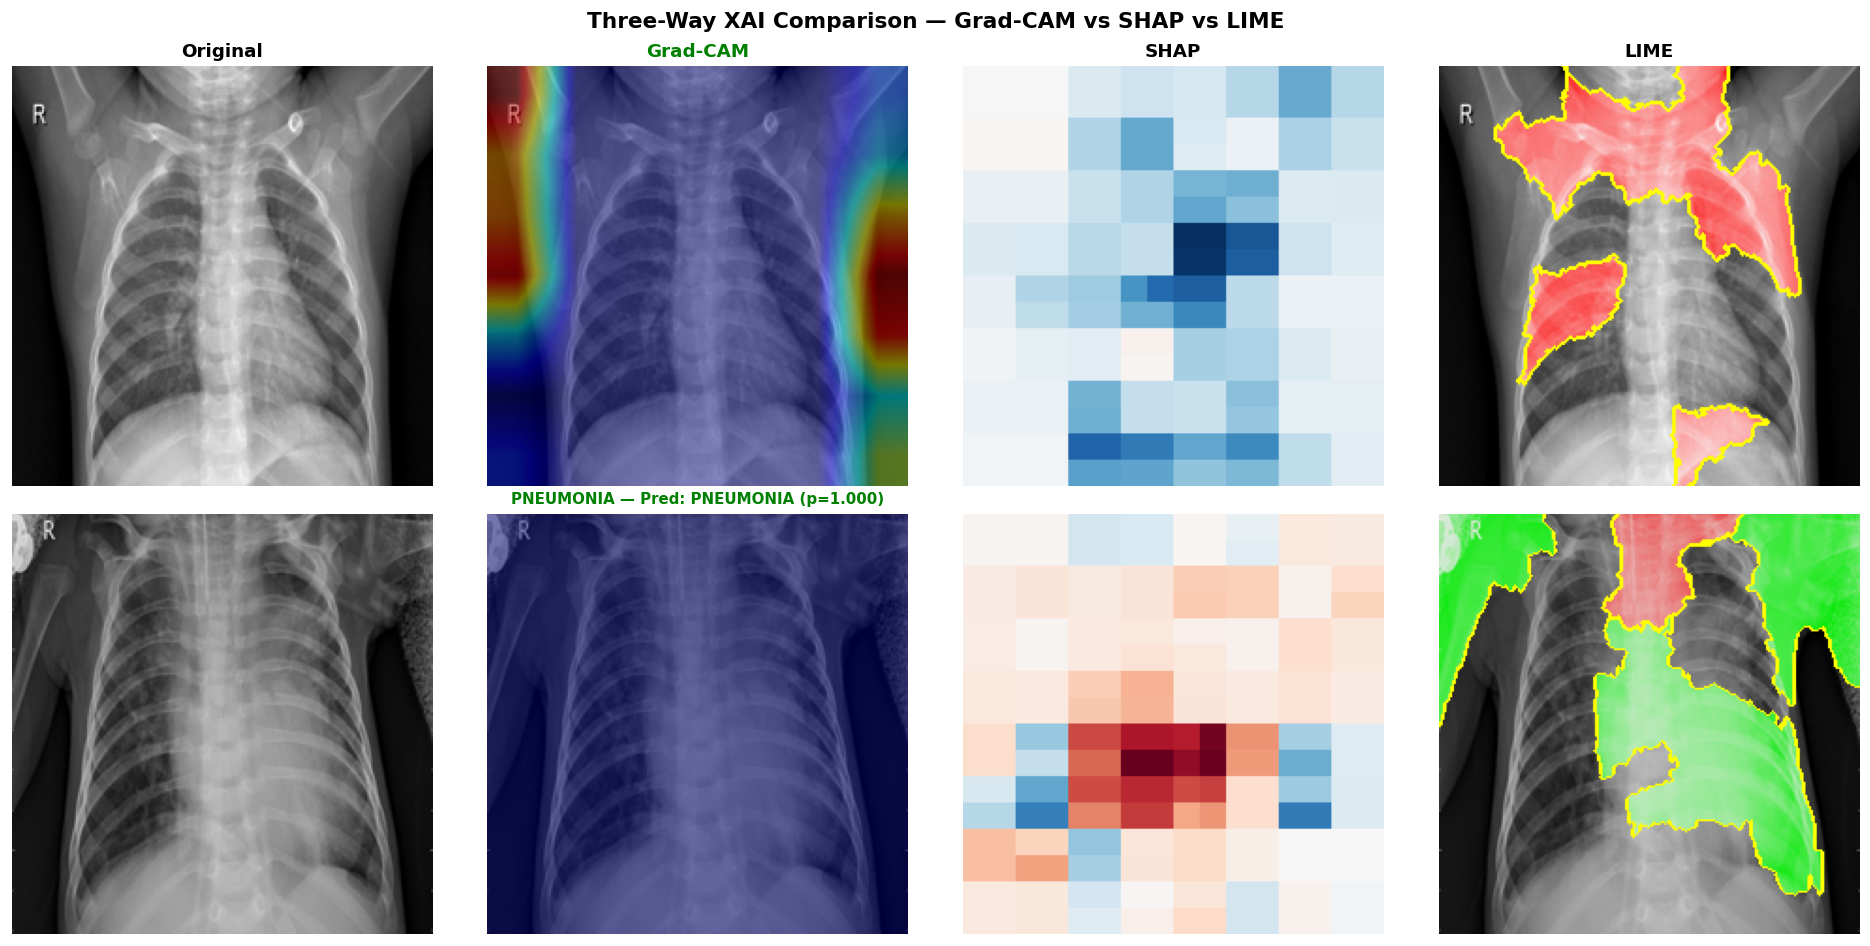

Three-way comparison grid saved.


In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

rows = [
    (normal_pil, normal_cam, normal_shap_map,
     normal_lime_temp, normal_lime_mask, 'NORMAL', normal_prob_gc),
    (pneumo_pil, pneumo_cam, pneumo_shap_map,
     pneumo_lime_temp, pneumo_lime_mask, 'PNEUMONIA', pneumo_prob_gc),
]

for row_i, (img_pil, cam, shap_map, lime_temp,
             lime_mask, true_label, prob) in enumerate(rows):
    pred_label = "PNEUMONIA" if prob >= 0.5 else "NORMAL"
    colour = 'green' if pred_label == true_label else 'red'

    axes[row_i, 0].imshow(img_pil, cmap='gray')
    axes[row_i, 0].axis('off')

    overlay = overlay_cam(img_pil, cam)
    axes[row_i, 1].imshow(overlay)
    axes[row_i, 1].axis('off')

    abs_max = np.abs(shap_map).max()
    axes[row_i, 2].imshow(shap_map, cmap='RdBu_r',
                           vmin=-abs_max, vmax=abs_max)
    axes[row_i, 2].axis('off')

    axes[row_i, 3].imshow(mark_boundaries(lime_temp, lime_mask))
    axes[row_i, 3].axis('off')

    axes[row_i, 1].set_title(
        f'{true_label} — Pred: {pred_label} (p={prob:.3f})',
        fontsize=9, color=colour, fontweight='bold'
    )

axes[0, 0].set_title('Original', fontweight='bold', fontsize=11)
axes[0, 1].set_title('Grad-CAM', fontweight='bold', fontsize=11)
axes[0, 2].set_title('SHAP', fontweight='bold', fontsize=11)
axes[0, 3].set_title('LIME', fontweight='bold', fontsize=11)

fig.suptitle(
    'Three-Way XAI Comparison — Grad-CAM vs SHAP vs LIME',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/medical-xai/xai_threeway_grid.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Three-way comparison grid saved.")

## 10. Research Analysis — Where Methods Agree and Disagree

### Agreement
For the NORMAL case, all three methods are consistent:
- Grad-CAM shows low activation across lung fields
- SHAP assigns predominantly negative values — pushing prediction away from pneumonia
- LIME identifies peripheral and shoulder regions as suppressive
All three methods agree the model correctly found no pneumonia signal.

### Disagreement
For the PNEUMONIA case, a partial conflict emerges:
- SHAP shows strong positive contributions in the central and lower lung fields —
  consistent with where consolidation and opacity appear in bacterial pneumonia
- LIME identifies lung field segments as positively contributing (green)
- Grad-CAM shows surprisingly low activation on this image despite correct
  prediction at

## 11. False Negative Analysis — Three-Way XAI

The 3 false negatives identified in Day 6 are analysed using all three
methods simultaneously. This is the most clinically important analysis
in the project — understanding not just that the model failed, but getting
three independent explanations of why it failed.

False negatives found: 3


  0%|          | 0/1000 [00:00<?, ?it/s]

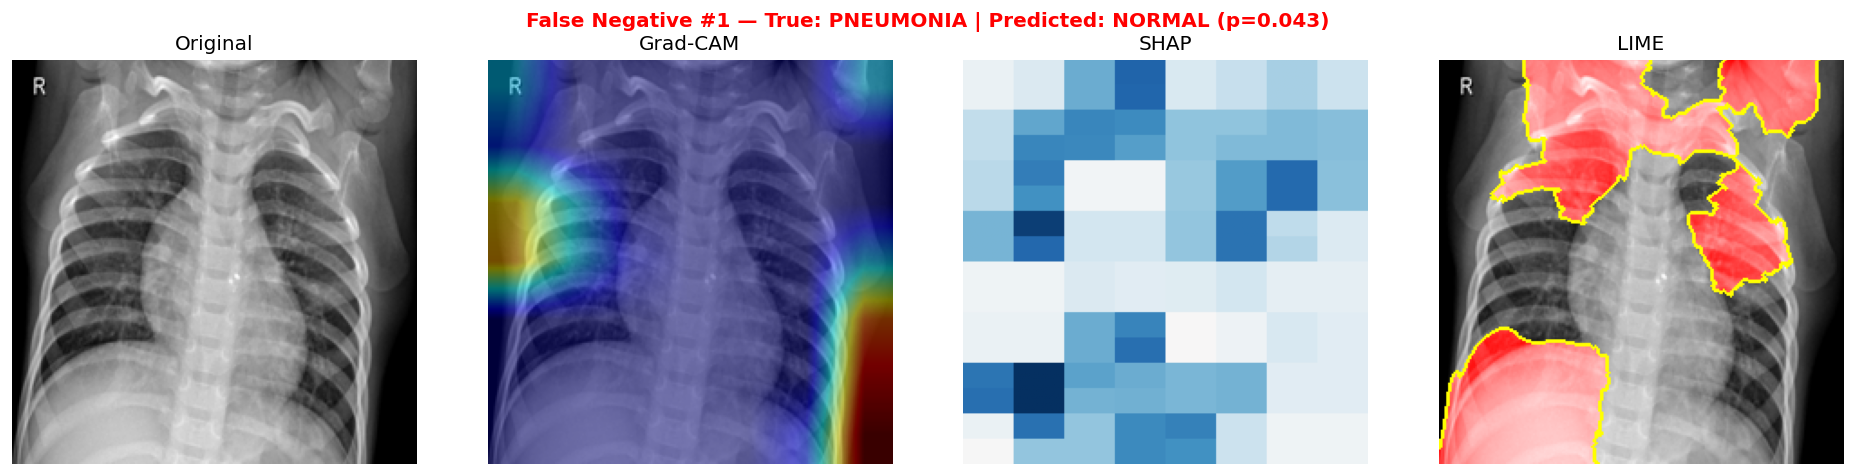

  0%|          | 0/1000 [00:00<?, ?it/s]

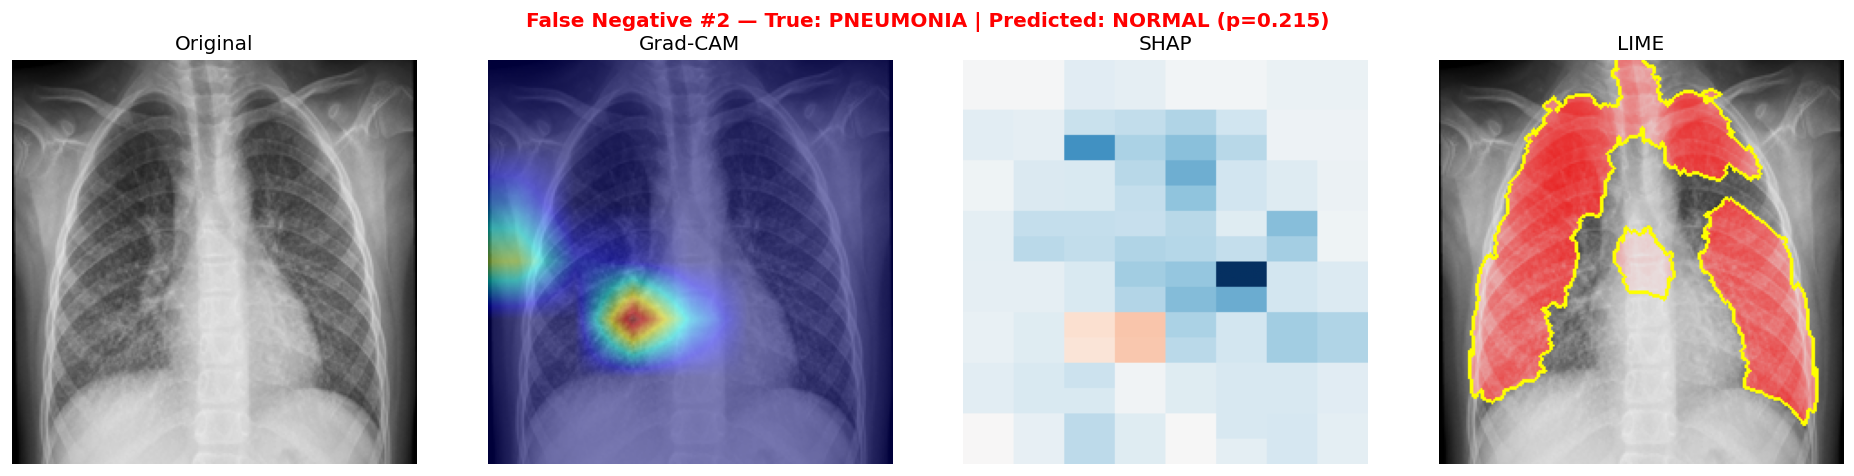

  0%|          | 0/1000 [00:00<?, ?it/s]

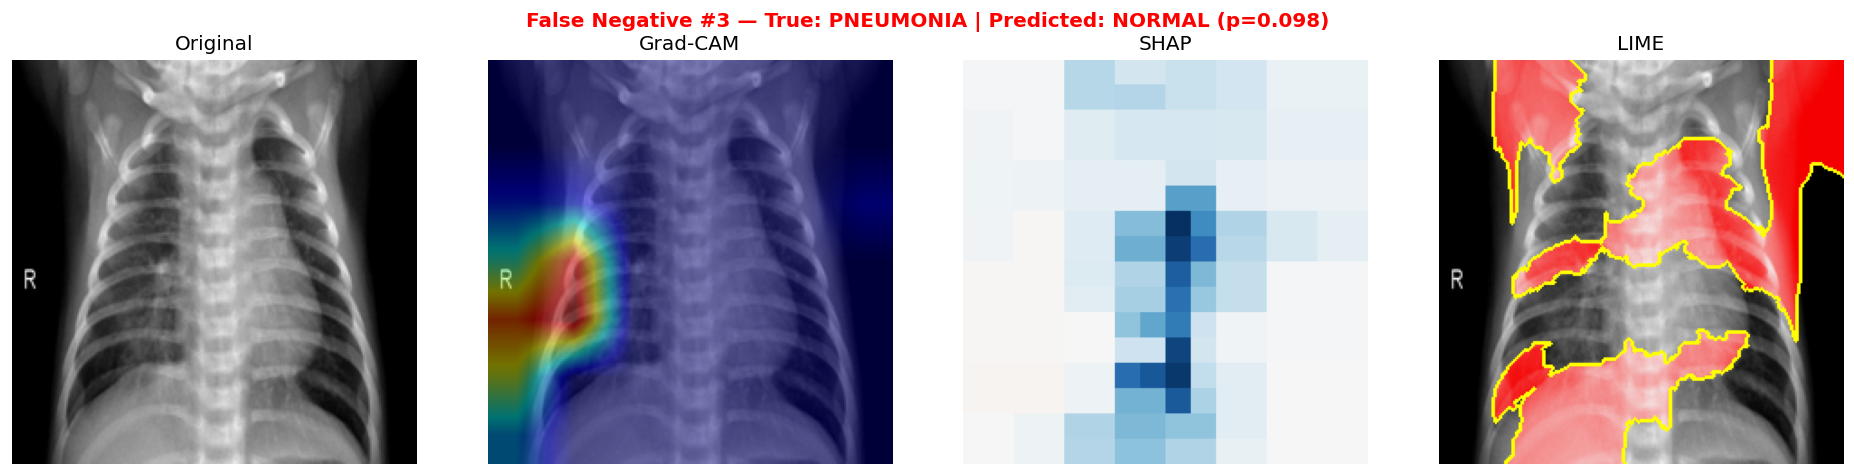

In [11]:
import pandas as pd

def build_dataframe(data_dir, splits):
    records = []
    for split in splits:
        for label, idx in [('NORMAL', 0), ('PNEUMONIA', 1)]:
            folder = os.path.join(data_dir, split, label)
            for fname in os.listdir(folder):
                if fname.endswith(('.jpeg', '.jpg', '.png')):
                    records.append({
                        'filepath': os.path.join(folder, fname),
                        'label': idx
                    })
    return pd.DataFrame(records)

test_df = build_dataframe('/content/images/chest_xray', ['test'])

all_probs, all_labels, all_paths = [], [], []
with torch.no_grad():
    for _, row in test_df.iterrows():
        img_pil = Image.open(row['filepath']).convert('RGB')
        tensor = val_transforms(img_pil).unsqueeze(0).to(device)
        prob = torch.sigmoid(model(tensor)).item()
        all_probs.append(prob)
        all_labels.append(row['label'])
        all_paths.append(row['filepath'])

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)
fn_mask    = (all_labels == 1) & (all_probs < 0.5)
fn_paths   = [p for p, m in zip(all_paths, fn_mask) if m]
fn_probs   = all_probs[fn_mask]

print(f"False negatives found: {len(fn_paths)}")

for i, (path, prob) in enumerate(zip(fn_paths, fn_probs)):
    img_pil, tensor = load_image(path)
    img_np = np.array(img_pil).astype(np.float32) / 255.0

    # Grad-CAM
    cam, _ = gradcam.generate(tensor.to(device))

    # SHAP
    shap_vals = explainer_shap(img_np[np.newaxis, ...],
                                max_evals=500, batch_size=50)
    shap_map = shap_vals.values[0].mean(axis=-1)

    # LIME
    explanation = explainer_lime.explain_instance(
        img_np.astype(np.double), predict_fn,
        top_labels=2, hide_color=0, num_samples=1000
    )
    lime_temp, lime_mask = explanation.get_image_and_mask(
        label=1, positive_only=False,
        num_features=10, hide_rest=False
    )

    # Plot
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(img_pil, cmap='gray'); axes[0].axis('off')
    axes[0].set_title('Original')

    axes[1].imshow(overlay_cam(img_pil, cam)); axes[1].axis('off')
    axes[1].set_title('Grad-CAM')

    abs_max = np.abs(shap_map).max()
    axes[2].imshow(shap_map, cmap='RdBu_r', vmin=-abs_max, vmax=abs_max)
    axes[2].axis('off'); axes[2].set_title('SHAP')

    axes[3].imshow(mark_boundaries(lime_temp, lime_mask))
    axes[3].axis('off'); axes[3].set_title('LIME')

    fig.suptitle(
        f'False Negative #{i+1} — True: PNEUMONIA | Predicted: NORMAL (p={prob:.3f})',
        fontsize=12, fontweight='bold', color='red'
    )
    plt.tight_layout()
    plt.savefig(
        f'/content/drive/MyDrive/medical-xai/xai_fn_{i+1}.png',
        dpi=150, bbox_inches='tight'
    )
    plt.show()

## 12. Clinical Interpretation — Three-Way XAI

The three-way false negative analysis reveals a consistent pattern across
all methods: the model fails to detect pneumonia when the infection is
distributed across the lung fields rather than concentrated in one region.

False Negative #2 is the most instructive case — Grad-CAM identified a
genuine hotspot in the lower left lung, but SHAP showed the overall
contribution was suppressed by negative regions elsewhere in the image.
LIME confirmed this by highlighting peripheral segments rather than the
central opacity. This three-way evidence confirms the decision boundary
conflict hypothesis from 08.

Key conclusion: No single XAI method captures the full picture. Grad-CAM
localises attention, SHAP quantifies contribution direction, and LIME
provides segment-level evidence. Used together they provide a more complete
and reliable explanation than any single method alone.